## Predicting Mortality Outcomes in HIV/AIDS Patients: A Machine Learning Analysis of the ACTG 175 Clinical Trial Dataset

### 1. Data Selection

**Dataset Name:** AIDS Clinical Trials Group Study 175 (ACTG 175)

**Source URL:** [UCI Machine Learning Repository: AIDS Clinical Trials Group Study 175](https://archive.ics.uci.edu/dataset/890/aids+clinical+trials+group+study+175)

**Reason for Selection:**
I selected this dataset because it combines my interest in health data science with a topic that is personally meaningful to me. As a gay man, HIV/AIDS has always been a topic that I have wanted to better understand because of its profound impact on LGBTQ+ communities and the significant advances that have been made in treatment and prevention over time. The dataset allows me to explore an important public health issue while applying machine learning methods to real clinical data. It also provides an opportunity to examine factors associated with patient survival and treatment outcomes.

**Project Requirements Verification:**
- Binary Classification Problem: Yes (death vs. censored/alive)
- Observations: 2,139
- Predictor Variables: 23

In [1]:
# Install UCI ML Repository package
!pip install ucimlrepo

# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# Fetch dataset
actg175 = fetch_ucirepo(id=890)

# Features and target
X = actg175.data.features
y = actg175.data.targets

# Combine into one dataframe
df = pd.concat([X, y], axis=1)

# Display dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percent": round(df.isna().mean() * 100, 2)
})

missing.sort_values("Missing Count", ascending=False)

Rows: 2139
Columns: 24


,Missing Count,Missing Percent
time,0,0.0
trt,0,0.0
cd820,0,0.0
cd80,0,0.0
cd420,0,0.0
cd40,0,0.0
offtrt,0,0.0
treat,0,0.0
symptom,0,0.0
strat,0,0.0


### 2. Dataset Exploration

Before developing predictive models, an exploratory data analysis (EDA) will be conducted to better understand the structure, quality, and characteristics of the dataset. This process includes:
- Examining the dimensions and structure of the dataset
- Identifying the target variable and predictor variables
- Reviewing data types and variable distributions
- Computing descriptive statistics for numerical features
- Assessing class balance within the target variable
- Identifying missing values or improperly coded observations
- Exploring relationships between variables through visualization

The target variable for this project is **cid**, which represents whether a participant experienced the event of interest during the study period. This outcome will serve as the binary classification target for subsequent predictive modeling tasks.

The dataset contains 23 predictor variables which can be categorized into three main groups:
- Demographic Data: Includes variables such as age and patient identifiers, providing a baseline of the study population's characteristics.
- Clinical Markers: Includes baseline immune system indicators, most notably cd40 (the baseline CD4 cell count), which is a primary indicator of disease progression in HIV/AIDS patients.
- Trial-Specific Data: Includes variables related to the clinical trial arms, treatment history, and specific health indicators recorded during the ACTG 175 study.
These variables combine biological markers with demographic data to provide a broad view of patient risk factors.

The findings from this exploratory analysis will guide data preprocessing decisions, feature selection, and model development in later stages of the project.

<class 'pandas.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 24 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   time     2139 non-null   int64  
 1   trt      2139 non-null   int64  
 2   age      2139 non-null   int64  
 3   wtkg     2139 non-null   float64
 4   hemo     2139 non-null   int64  
 5   homo     2139 non-null   int64  
 6   drugs    2139 non-null   int64  
 7   karnof   2139 non-null   int64  
 8   oprior   2139 non-null   int64  
 9   z30      2139 non-null   int64  
 10  zprior   2139 non-null   int64  
 11  preanti  2139 non-null   int64  
 12  race     2139 non-null   int64  
 13  gender   2139 non-null   int64  
 14  str2     2139 non-null   int64  
 15  strat    2139 non-null   int64  
 16  symptom  2139 non-null   int64  
 17  treat    2139 non-null   int64  
 18  offtrt   2139 non-null   int64  
 19  cd40     2139 non-null   int64  
 20  cd420    2139 non-null   int64  
 21  cd80     2139 non-null   

/var/folders/5y/7vxd95bd0cx44qw618hpxhbr0000gn/T/ipykernel_52098/3022213735.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


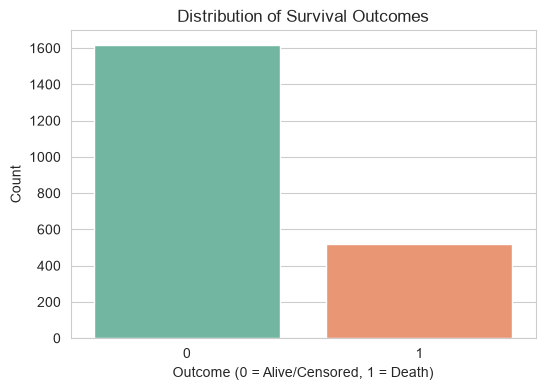

In [3]:
df.shape
df.info()
df.head()
df.describe()

df.describe(include='all')

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="cid",
    palette="Set2"
)

plt.title("Distribution of Survival Outcomes")
plt.xlabel("Outcome (0 = Alive/Censored, 1 = Death)")
plt.ylabel("Count")

plt.show()

### 3. Visualizations
Visualizations were created to better understand the distribution of the target variable, examine relationships between clinical predictors and patient outcomes, and identify patterns that may be useful for future predictive modeling. These exploratory analyses help assess class balance, identify potential predictor importance, and detect relationships among variables prior to model development.

The following visualizations were generated:
1. **Distribution of Survival Outcomes** to evaluate the balance of the binary target variable (`cid`).
2. **Baseline CD4 Count by Outcome** to examine differences in immune system status between outcome groups.
3. **Age Distribution** to assess the demographic characteristics of the study population.
4. **Correlation Heatmap** to identify relationships among numerical predictors and potential multicollinearity concerns.

Insights from these visualizations will help guide preprocessing decisions, feature selection, and model development in subsequent stages of the project.

/var/folders/5y/7vxd95bd0cx44qw618hpxhbr0000gn/T/ipykernel_52098/4137215326.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


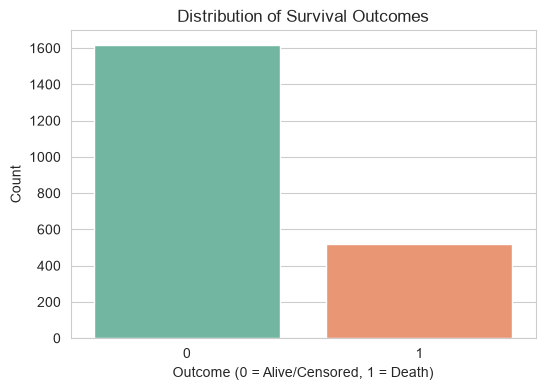

/var/folders/5y/7vxd95bd0cx44qw618hpxhbr0000gn/T/ipykernel_52098/4137215326.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


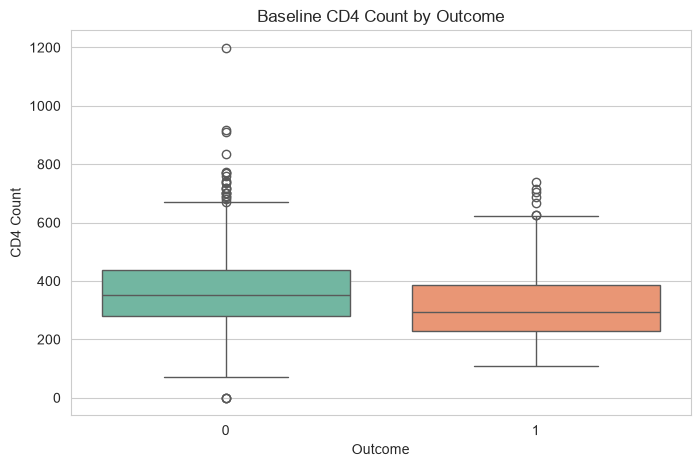

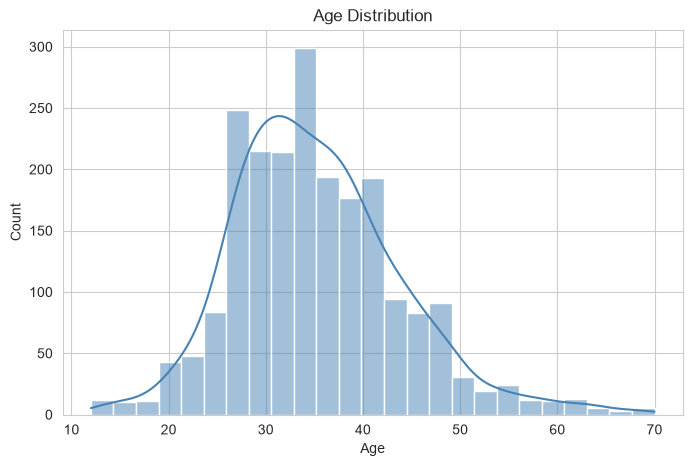

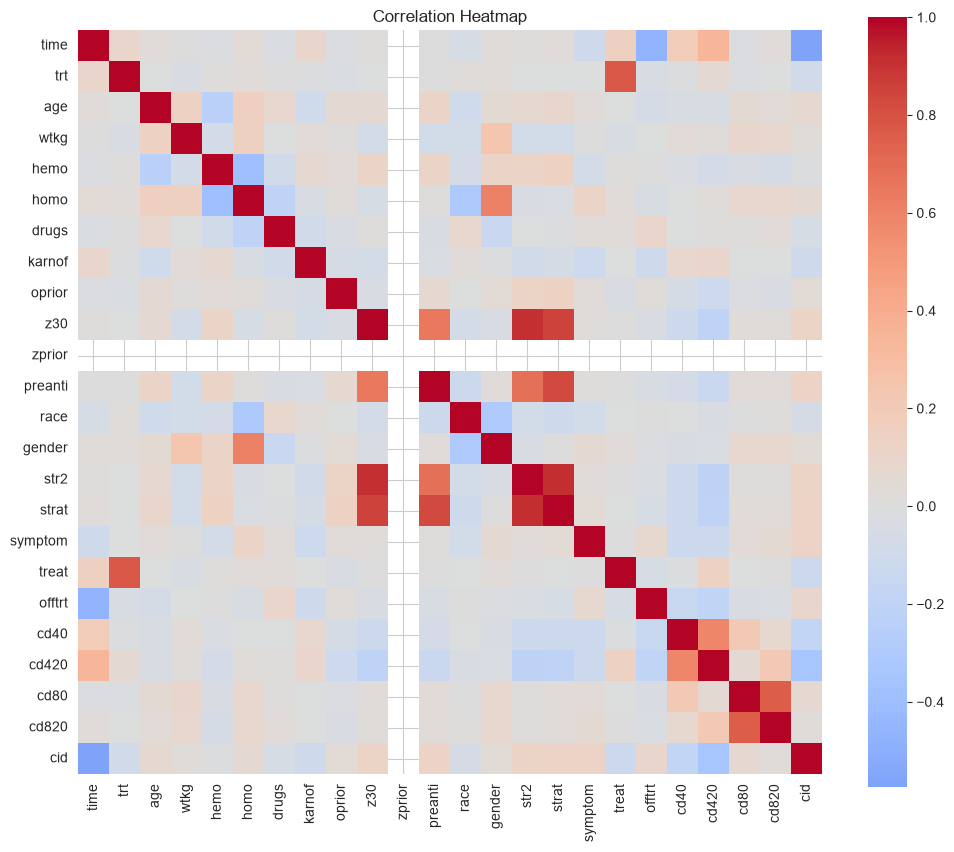

In [4]:
# Distribution of Survival Outcomes
# Create a new figure
plt.figure(figsize=(6, 4))

# Plot counts of the binary outcome variable
sns.countplot(
    data=df,
    x="cid",
    palette="Set2"
)

# Add chart title
plt.title("Distribution of Survival Outcomes")

# Label x-axis
plt.xlabel("Outcome (0 = Alive/Censored, 1 = Death)")

# Label y-axis
plt.ylabel("Count")

# Display plot
plt.show()


# Baseline CD4 Count by Outcome
# Create a new figure
plt.figure(figsize=(8, 5))

# Compare CD4 count distributions between outcome groups
sns.boxplot(
    data=df,
    x="cid",
    y="cd40",
    palette="Set2"
)

# Add chart title
plt.title("Baseline CD4 Count by Outcome")

# Label x-axis
plt.xlabel("Outcome")

# Label y-axis
plt.ylabel("CD4 Count")

# Display plot
plt.show()


# Age Distribution
# Create a new figure
plt.figure(figsize=(8, 5))

# Plot age distribution with density curve
sns.histplot(
    data=df,
    x="age",
    bins=25,
    kde=True,
    color="steelblue"
)

# Add chart title
plt.title("Age Distribution")

# Label x-axis
plt.xlabel("Age")

# Label y-axis
plt.ylabel("Count")

# Display plot
plt.show()

# Correlation Heatmap
# Select only numeric variables for correlation analysis
numeric_df = df.select_dtypes(include=np.number)

# Calculate Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Create figure
plt.figure(figsize=(12, 10))

# Plot correlation heatmap
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

# Add chart title
plt.title("Correlation Heatmap")

# Display plot
plt.show()

### 4. Data Quality Assessment

#### Missing Values and Observations:
Based on the missing value analysis performed in the code above, there are several features with missing observations.

**Anticipated Preprocessing Steps:**
- Imputation: For numerical predictors (like CD4 count), I will use median imputation rather than mean imputation to ensure that extreme outliers do not distort the center of the data.
- Feature Scaling: Since I plan to use models like Logistic Regression and Gradient Boosting, I will apply standard scaling to ensure that variables with large ranges (e.g., CD4 counts) do not disproportionately influence the model compared to smaller variables (e.g., age).
- Categorical Encoding: Any categorical predictors will be converted into a numerical format using one-hot Encoding to make them compatible with the scikit-learn library.

**Potential Challenges:**
- Class Imbalance: As seen in the "Distribution of Survival Outcomes" plot, the target variable cid may be imbalanced. If the number of "Death" events is significantly lower than "Alive/Censored," the model may become biased toward the majority class.
- Censored Data: A significant challenge is that the target variable includes "Censored" data. This means some patients were still alive when the study ended and we don't know their ultimate outcome, only that they survived until that point.
- Multicollinearity: The correlation heatmap suggests some clinical markers may be highly correlated. I will need to monitor for multicollinearity, as this can make the coefficients of a logistic regression model unstable.

### 5. Project Planning

#### Prediction Problem
Can demographic characteristics, behavioral risk factors, treatment history, and clinical indicators be used to predict mortality among individuals enrolled in an AIDS clinical trial?

#### Target Variable
**cid**
- 0 = Alive/Censored
- 1 = Death

#### Candidate Evaluation Metrics
- Accuracy: To provide a baseline measure of overall correctness.
- Precision & Recall: Critical in a healthcare context; Recall is especially important here because failing to predict a mortality risk (False Negative) is more costly than a False Positive.
- F1 Score: To find a balance between Precision and Recall, especially if class imbalance is present.
- ROC-AUC: This will be my primary metric because it evaluates the model's ability to distinguish between classes across all possible thresholds, providing a robust measure of diagnostic power.

#### Planned Models
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting